# Project Performance - Strong Signal Backtest

`2020_H1 ~ 2025_H2` 기간별로 `strong_in`, `strong_out` 종목의 반기 변경 이벤트 전후 수익률을 계산합니다.

## 기준
- 상반기(`H1`): `5/1` 기준 이후 관측 가능한 첫 가격을 매수 기준으로 사용, `6월 둘째 주 금요일`을 매도 기준으로 사용
- 하반기(`H2`): `11/1` 기준 이후 관측 가능한 첫 가격을 매수 기준으로 사용, `12월 둘째 주 금요일`을 매도 기준으로 사용
- 벤치마크: 변경 직전 KOSPI200 구성 종목(`prev_member == 1`)의 평균 수익률

## 데이터 소스
- 예측/정답: `data/raw/kospi_db_full_20260320.sql`의 `predictions`, `labels`, `period`
- 가격: 우선 `daily_raw.parquet`를 사용하고, 없으면 SQL dump의 `kospi_friday_daily`를 사용

## 참고
- 현재 워크스페이스에는 `daily_raw.parquet`가 없으면 `kospi_friday_daily`를 사용하게 됩니다.
- 이 경우 매수일은 정확한 "첫 거래일"이 아니라 "기준일 이후 첫 관측일(주간 금요일 데이터)"이 됩니다.
- `2020_H1`은 현재 SQL dump에 예측 데이터가 없어 요약표에서 결측으로 표시될 수 있습니다.


In [1]:
import ast
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

BASE_DIR = Path.cwd()
SQL_DUMP_PATH = BASE_DIR / "data" / "raw" / "kospi_db_full_20260320.sql"
DAILY_PARQUET_PATH = BASE_DIR / "daily_raw.parquet"

print("BASE_DIR:", BASE_DIR)
print("SQL_DUMP_PATH exists:", SQL_DUMP_PATH.exists())
print("DAILY_PARQUET_PATH exists:", DAILY_PARQUET_PATH.exists())


BASE_DIR: c:\Users\Admin\Desktop\Project\Next200\Next200_v1
SQL_DUMP_PATH exists: True
DAILY_PARQUET_PATH exists: False


In [18]:
def normalize_ticker(value):
    text = str(value).strip()
    if text.lower() in {"none", "nan", ""}:
        return pd.NA
    return text.lstrip("0") or "0"


def load_sql_insert_table(sql_text: str, table_name: str, columns: list[str]) -> pd.DataFrame:
    rows = []
    pattern = rf"INSERT INTO `{table_name}` VALUES (.*?);\n"
    for match in re.finditer(pattern, sql_text, flags=re.S):
        raw = "[" + match.group(1).replace("NULL", "None") + "]"
        rows.extend(ast.literal_eval(raw))
    return pd.DataFrame(rows, columns=columns)


def load_from_sql_dump(sql_path: Path):
    sql_text = sql_path.read_text(encoding="utf-8", errors="ignore")

    predictions = load_sql_insert_table(
        sql_text,
        "predictions",
        [
            "id",
            "run_date",
            "period",
            "ticker",
            "company",
            "score",
            "pred_rank",
            "period_rank",
            "pred_top200",
            "strong_in",
            "strong_out",
            "prev_member",
            "model_version",
        ],
    )

    labels = load_sql_insert_table(
        sql_text,
        "labels",
        ["period", "ticker", "was_member", "label_in", "label_out", "actual_rank", "is_member"],
    )

    periods = load_sql_insert_table(
        sql_text,
        "period",
        ["period", "period_start", "period_end"],
    )

    friday_prices = load_sql_insert_table(
        sql_text,
        "kospi_friday_daily",
        ["date", "ticker", "company", "close", "volume", "trading_value", "mktcap", "shares", "mktcap_rank"],
    )

    for df in [predictions, labels, friday_prices]:
        df["ticker"] = df["ticker"].map(normalize_ticker)

    predictions["run_date"] = pd.to_datetime(predictions["run_date"])
    periods["period_start"] = pd.to_datetime(periods["period_start"])
    periods["period_end"] = pd.to_datetime(periods["period_end"])
    friday_prices["date"] = pd.to_datetime(friday_prices["date"].astype(str))

    return predictions, labels, periods, friday_prices


predictions, labels, periods, friday_prices = load_from_sql_dump(SQL_DUMP_PATH)

print("predictions:", predictions.shape)
print("labels:", labels.shape)
print("periods:", periods.shape)
print("friday_prices:", friday_prices.shape)
print("prediction periods:", predictions["period"].drop_duplicates().tolist())


predictions: (2983, 13)
labels: (2491, 7)
periods: (13, 3)
friday_prices: (319010, 9)
prediction periods: ['2020_H2', '2021_H1', '2021_H2', '2022_H1', '2022_H2', '2023_H1', '2023_H2', '2024_H1', '2024_H2', '2025_H1', '2025_H2']


In [19]:
def load_price_data(daily_parquet_path: Path, fallback_prices: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    if daily_parquet_path.exists():
        daily = pd.read_parquet(daily_parquet_path).copy()
        rename_map = {}
        if "종가" in daily.columns:
            rename_map["종가"] = "close"
        if "date" not in daily.columns:
            raise ValueError("daily_raw.parquet 에 date 컬럼이 없습니다.")
        daily = daily.rename(columns=rename_map)
        if "close" not in daily.columns:
            raise ValueError("daily_raw.parquet 에 close 또는 종가 컬럼이 없습니다.")
        daily["date"] = pd.to_datetime(daily["date"])
        daily["ticker"] = daily["ticker"].map(normalize_ticker)
        price_df = daily[["date", "ticker", "close"]].dropna().drop_duplicates()
        return price_df, "daily_raw.parquet"

    price_df = fallback_prices[["date", "ticker", "close"]].dropna().drop_duplicates()
    return price_df, "kospi_friday_daily"


price_df, price_source = load_price_data(DAILY_PARQUET_PATH, friday_prices)
observation_days = pd.DatetimeIndex(sorted(price_df["date"].unique()))

print("price source:", price_source)
print("price rows:", len(price_df))
print("price date range:", observation_days.min().date(), "~", observation_days.max().date())


price source: kospi_friday_daily
price rows: 319010
price date range: 2019-05-03 ~ 2026-03-13


In [20]:
def get_next_observation(target_date: str | pd.Timestamp, dates: pd.DatetimeIndex):
    target = pd.Timestamp(target_date)
    valid = dates[dates >= target]
    return valid[0] if len(valid) else pd.NaT


def get_prev_observation(target_date: str | pd.Timestamp, dates: pd.DatetimeIndex):
    target = pd.Timestamp(target_date)
    valid = dates[dates <= target]
    return valid[-1] if len(valid) else pd.NaT


def get_second_friday(year: int, month: int) -> pd.Timestamp:
    first_day = pd.Timestamp(year=year, month=month, day=1)
    days_to_friday = (4 - first_day.weekday()) % 7
    first_friday = first_day + pd.Timedelta(days=days_to_friday)
    return first_friday + pd.Timedelta(weeks=1)


def build_calendar(period: str, dates: pd.DatetimeIndex) -> dict:
    year = int(period[:4])
    half = period[-2:]
    buy_ref = pd.Timestamp(year=year, month=5 if half == "H1" else 11, day=1)
    sell_ref = get_second_friday(year, 6 if half == "H1" else 12)

    return {
        "buy_reference": buy_ref,
        "sell_reference": sell_ref,
        "buy_date": get_next_observation(buy_ref, dates),
        "sell_date": get_prev_observation(sell_ref, dates),
    }


sample_calendar = {period: build_calendar(period, observation_days) for period in ["2020_H1", "2025_H1", "2025_H2"]}
sample_calendar


{'2020_H1': {'buy_reference': Timestamp('2020-05-01 00:00:00'),
  'sell_reference': Timestamp('2020-06-12 00:00:00'),
  'buy_date': Timestamp('2020-05-08 00:00:00'),
  'sell_date': Timestamp('2020-06-12 00:00:00')},
 '2025_H1': {'buy_reference': Timestamp('2025-05-01 00:00:00'),
  'sell_reference': Timestamp('2025-06-13 00:00:00'),
  'buy_date': Timestamp('2025-05-02 00:00:00'),
  'sell_date': Timestamp('2025-06-13 00:00:00')},
 '2025_H2': {'buy_reference': Timestamp('2025-11-01 00:00:00'),
  'sell_reference': Timestamp('2025-12-12 00:00:00'),
  'buy_date': Timestamp('2025-11-07 00:00:00'),
  'sell_date': Timestamp('2025-12-12 00:00:00')}}

In [21]:
def compute_returns_for_subset(subset: pd.DataFrame, buy_date: pd.Timestamp, sell_date: pd.Timestamp, price_frame: pd.DataFrame):
    if subset.empty or pd.isna(buy_date) or pd.isna(sell_date):
        result = subset.copy()
        result["buy_price"] = np.nan
        result["sell_price"] = np.nan
        result["return_pct"] = np.nan
        return result

    buy_prices = (
        price_frame.loc[price_frame["date"] == buy_date, ["ticker", "close"]]
        .rename(columns={"close": "buy_price"})
        .drop_duplicates(subset=["ticker"])
    )
    sell_prices = (
        price_frame.loc[price_frame["date"] == sell_date, ["ticker", "close"]]
        .rename(columns={"close": "sell_price"})
        .drop_duplicates(subset=["ticker"])
    )

    result = subset.merge(buy_prices, on="ticker", how="left").merge(sell_prices, on="ticker", how="left")
    result["return_pct"] = (result["sell_price"] - result["buy_price"]) / result["buy_price"] * 100
    return result


def analyze_period(period: str, predictions_df: pd.DataFrame, labels_df: pd.DataFrame, price_frame: pd.DataFrame, dates: pd.DatetimeIndex):
    calendar = build_calendar(period, dates)
    period_predictions = predictions_df.loc[predictions_df["period"] == period].copy()

    if period_predictions.empty:
        return {
            "summary": {
                "period": period,
                "price_source": price_source,
                "buy_reference": calendar["buy_reference"],
                "buy_date": calendar["buy_date"],
                "sell_reference": calendar["sell_reference"],
                "sell_date": calendar["sell_date"],
                "strong_in_count": np.nan,
                "strong_in_avg_return": np.nan,
                "strong_in_actual_avg_return": np.nan,
                "strong_out_count": np.nan,
                "strong_out_avg_return": np.nan,
                "strong_out_actual_avg_return": np.nan,
                "benchmark_avg_return": np.nan,
                "strong_in_excess_vs_benchmark": np.nan,
                "strong_out_excess_vs_benchmark": np.nan,
                "status": "prediction_missing",
            },
            "details": {"strong_in": pd.DataFrame(), "strong_out": pd.DataFrame(), "benchmark": pd.DataFrame()},
        }

    label_cols = labels_df.loc[labels_df["period"] == period, ["ticker", "label_in", "label_out", "is_member"]].copy()
    enriched = period_predictions.merge(label_cols, on="ticker", how="left")

    strong_in = compute_returns_for_subset(enriched.loc[enriched["strong_in"] == 1].copy(), calendar["buy_date"], calendar["sell_date"], price_frame)
    strong_out = compute_returns_for_subset(enriched.loc[enriched["strong_out"] == 1].copy(), calendar["buy_date"], calendar["sell_date"], price_frame)
    benchmark = compute_returns_for_subset(enriched.loc[enriched["prev_member"] == 1, ["ticker", "company", "prev_member"]].copy(), calendar["buy_date"], calendar["sell_date"], price_frame)

    benchmark_avg = benchmark["return_pct"].mean()

    summary = {
        "period": period,
        "price_source": price_source,
        "buy_reference": calendar["buy_reference"],
        "buy_date": calendar["buy_date"],
        "sell_reference": calendar["sell_reference"],
        "sell_date": calendar["sell_date"],
        "strong_in_count": int(len(strong_in)),
        "strong_in_avg_return": strong_in["return_pct"].mean(),
        "strong_in_actual_avg_return": strong_in.loc[strong_in["label_in"] == 1, "return_pct"].mean(),
        "strong_out_count": int(len(strong_out)),
        "strong_out_avg_return": strong_out["return_pct"].mean(),
        "strong_out_actual_avg_return": strong_out.loc[strong_out["label_out"] == 1, "return_pct"].mean(),
        "benchmark_avg_return": benchmark_avg,
        "strong_in_excess_vs_benchmark": strong_in["return_pct"].mean() - benchmark_avg,
        "strong_out_excess_vs_benchmark": strong_out["return_pct"].mean() - benchmark_avg,
        "status": "ok",
    }

    detail_frames = {
        "strong_in": strong_in.sort_values(["return_pct", "score"], ascending=[False, False]).reset_index(drop=True),
        "strong_out": strong_out.sort_values(["return_pct", "score"], ascending=[True, False]).reset_index(drop=True),
        "benchmark": benchmark.sort_values("return_pct", ascending=False).reset_index(drop=True),
    }
    return {"summary": summary, "details": detail_frames}


In [22]:
target_periods = [f"{year}_H{half}" for year in range(2020, 2026) for half in [1, 2]]
analysis_result = {period: analyze_period(period, predictions, labels, price_df, observation_days) for period in target_periods}

summary_df = pd.DataFrame([analysis_result[period]["summary"] for period in target_periods])
summary_df


,period,price_source,buy_reference,buy_date,sell_reference,sell_date,strong_in_count,strong_in_avg_return,strong_in_actual_avg_return,strong_out_count,strong_out_avg_return,strong_out_actual_avg_return,benchmark_avg_return,strong_in_excess_vs_benchmark,strong_out_excess_vs_benchmark,status
0,2020_H1,kospi_friday_daily,2020-05-01,2020-05-08,2020-06-12,2020-06-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,prediction_missing
1,2020_H2,kospi_friday_daily,2020-11-01,2020-11-06,2020-12-11,2020-12-11,23.0,16.302842,26.476902,10.0,6.388767,5.828423,12.115182,4.187661,-5.726415,ok
2,2021_H1,kospi_friday_daily,2021-05-01,2021-05-07,2021-06-11,2021-06-11,17.0,10.371696,33.913571,10.0,3.700092,8.252910,3.631316,6.740379,0.068776,ok
3,2021_H2,kospi_friday_daily,2021-11-01,2021-11-05,2021-12-10,2021-12-10,15.0,2.652486,-8.002312,11.0,-2.802604,3.482725,-2.539566,5.192052,-0.263039,ok
4,2022_H1,kospi_friday_daily,2022-05-01,2022-05-06,2022-06-10,2022-06-10,15.0,-8.666138,-14.851472,8.0,-3.665233,-4.516461,-1.266900,-7.399238,-2.398332,ok
5,2022_H2,kospi_friday_daily,2022-11-01,2022-11-04,2022-12-09,2022-12-09,11.0,7.070046,-8.333333,10.0,7.090442,11.616954,6.033478,1.036568,1.056964,ok
6,2023_H1,kospi_friday_daily,2023-05-01,2023-05-12,2023-06-09,2023-06-09,6.0,3.617157,3.090588,5.0,-1.936470,-5.308551,7.342303,-3.725147,-9.278773,ok
7,2023_H2,kospi_friday_daily,2023-11-01,2023-11-03,2023-12-08,2023-12-08,14.0,6.931196,6.679934,8.0,6.805119,6.805119,7.376355,-0.445159,-0.571236,ok
8,2024_H1,kospi_friday_daily,2024-05-01,2024-05-03,2024-06-14,2024-06-14,15.0,3.361011,9.759438,13.0,1.861854,-1.228292,2.506098,0.854913,-0.644244,ok
9,2024_H2,kospi_friday_daily,2024-11-01,2024-11-01,2024-12-13,2024-12-13,12.0,-9.549778,-3.609147,12.0,-9.853515,-10.699643,-2.846797,-6.702981,-7.006718,ok


In [23]:
summary_view = summary_df.copy()

date_cols = ["buy_reference", "buy_date", "sell_reference", "sell_date"]
for col in date_cols:
    summary_view[col] = pd.to_datetime(summary_view[col], errors="coerce").dt.strftime("%Y-%m-%d")

metric_cols = [
    "strong_in_avg_return",
    "strong_in_actual_avg_return",
    "strong_out_avg_return",
    "strong_out_actual_avg_return",
    "benchmark_avg_return",
    "strong_in_excess_vs_benchmark",
    "strong_out_excess_vs_benchmark",
]

for col in metric_cols:
    summary_view[col] = summary_view[col].map(lambda x: f"{x:+.2f}%" if pd.notna(x) else "N/A")

summary_view


,period,price_source,buy_reference,buy_date,sell_reference,sell_date,strong_in_count,strong_in_avg_return,strong_in_actual_avg_return,strong_out_count,strong_out_avg_return,strong_out_actual_avg_return,benchmark_avg_return,strong_in_excess_vs_benchmark,strong_out_excess_vs_benchmark,status
0,2020_H1,kospi_friday_daily,2020-05-01,2020-05-08,2020-06-12,2020-06-12,NaN,N/A,N/A,NaN,N/A,N/A,N/A,N/A,N/A,prediction_missing
1,2020_H2,kospi_friday_daily,2020-11-01,2020-11-06,2020-12-11,2020-12-11,23.0,+16.30%,+26.48%,10.0,+6.39%,+5.83%,+12.12%,+4.19%,-5.73%,ok
2,2021_H1,kospi_friday_daily,2021-05-01,2021-05-07,2021-06-11,2021-06-11,17.0,+10.37%,+33.91%,10.0,+3.70%,+8.25%,+3.63%,+6.74%,+0.07%,ok
3,2021_H2,kospi_friday_daily,2021-11-01,2021-11-05,2021-12-10,2021-12-10,15.0,+2.65%,-8.00%,11.0,-2.80%,+3.48%,-2.54%,+5.19%,-0.26%,ok
4,2022_H1,kospi_friday_daily,2022-05-01,2022-05-06,2022-06-10,2022-06-10,15.0,-8.67%,-14.85%,8.0,-3.67%,-4.52%,-1.27%,-7.40%,-2.40%,ok
5,2022_H2,kospi_friday_daily,2022-11-01,2022-11-04,2022-12-09,2022-12-09,11.0,+7.07%,-8.33%,10.0,+7.09%,+11.62%,+6.03%,+1.04%,+1.06%,ok
6,2023_H1,kospi_friday_daily,2023-05-01,2023-05-12,2023-06-09,2023-06-09,6.0,+3.62%,+3.09%,5.0,-1.94%,-5.31%,+7.34%,-3.73%,-9.28%,ok
7,2023_H2,kospi_friday_daily,2023-11-01,2023-11-03,2023-12-08,2023-12-08,14.0,+6.93%,+6.68%,8.0,+6.81%,+6.81%,+7.38%,-0.45%,-0.57%,ok
8,2024_H1,kospi_friday_daily,2024-05-01,2024-05-03,2024-06-14,2024-06-14,15.0,+3.36%,+9.76%,13.0,+1.86%,-1.23%,+2.51%,+0.85%,-0.64%,ok
9,2024_H2,kospi_friday_daily,2024-11-01,2024-11-01,2024-12-13,2024-12-13,12.0,-9.55%,-3.61%,12.0,-9.85%,-10.70%,-2.85%,-6.70%,-7.01%,ok


In [24]:
display_columns = [
    "period",
    "buy_reference",
    "buy_date",
    "sell_reference",
    "sell_date",
    "strong_in_count",
    "strong_in_avg_return",
    "strong_out_count",
    "strong_out_avg_return",
    "benchmark_avg_return",
    "strong_in_excess_vs_benchmark",
    "strong_out_excess_vs_benchmark",
    "status",
]

summary_view[display_columns]


,period,buy_reference,buy_date,sell_reference,sell_date,strong_in_count,strong_in_avg_return,strong_out_count,strong_out_avg_return,benchmark_avg_return,strong_in_excess_vs_benchmark,strong_out_excess_vs_benchmark,status
0,2020_H1,2020-05-01,2020-05-08,2020-06-12,2020-06-12,NaN,N/A,NaN,N/A,N/A,N/A,N/A,prediction_missing
1,2020_H2,2020-11-01,2020-11-06,2020-12-11,2020-12-11,23.0,+16.30%,10.0,+6.39%,+12.12%,+4.19%,-5.73%,ok
2,2021_H1,2021-05-01,2021-05-07,2021-06-11,2021-06-11,17.0,+10.37%,10.0,+3.70%,+3.63%,+6.74%,+0.07%,ok
3,2021_H2,2021-11-01,2021-11-05,2021-12-10,2021-12-10,15.0,+2.65%,11.0,-2.80%,-2.54%,+5.19%,-0.26%,ok
4,2022_H1,2022-05-01,2022-05-06,2022-06-10,2022-06-10,15.0,-8.67%,8.0,-3.67%,-1.27%,-7.40%,-2.40%,ok
5,2022_H2,2022-11-01,2022-11-04,2022-12-09,2022-12-09,11.0,+7.07%,10.0,+7.09%,+6.03%,+1.04%,+1.06%,ok
6,2023_H1,2023-05-01,2023-05-12,2023-06-09,2023-06-09,6.0,+3.62%,5.0,-1.94%,+7.34%,-3.73%,-9.28%,ok
7,2023_H2,2023-11-01,2023-11-03,2023-12-08,2023-12-08,14.0,+6.93%,8.0,+6.81%,+7.38%,-0.45%,-0.57%,ok
8,2024_H1,2024-05-01,2024-05-03,2024-06-14,2024-06-14,15.0,+3.36%,13.0,+1.86%,+2.51%,+0.85%,-0.64%,ok
9,2024_H2,2024-11-01,2024-11-01,2024-12-13,2024-12-13,12.0,-9.55%,12.0,-9.85%,-2.85%,-6.70%,-7.01%,ok


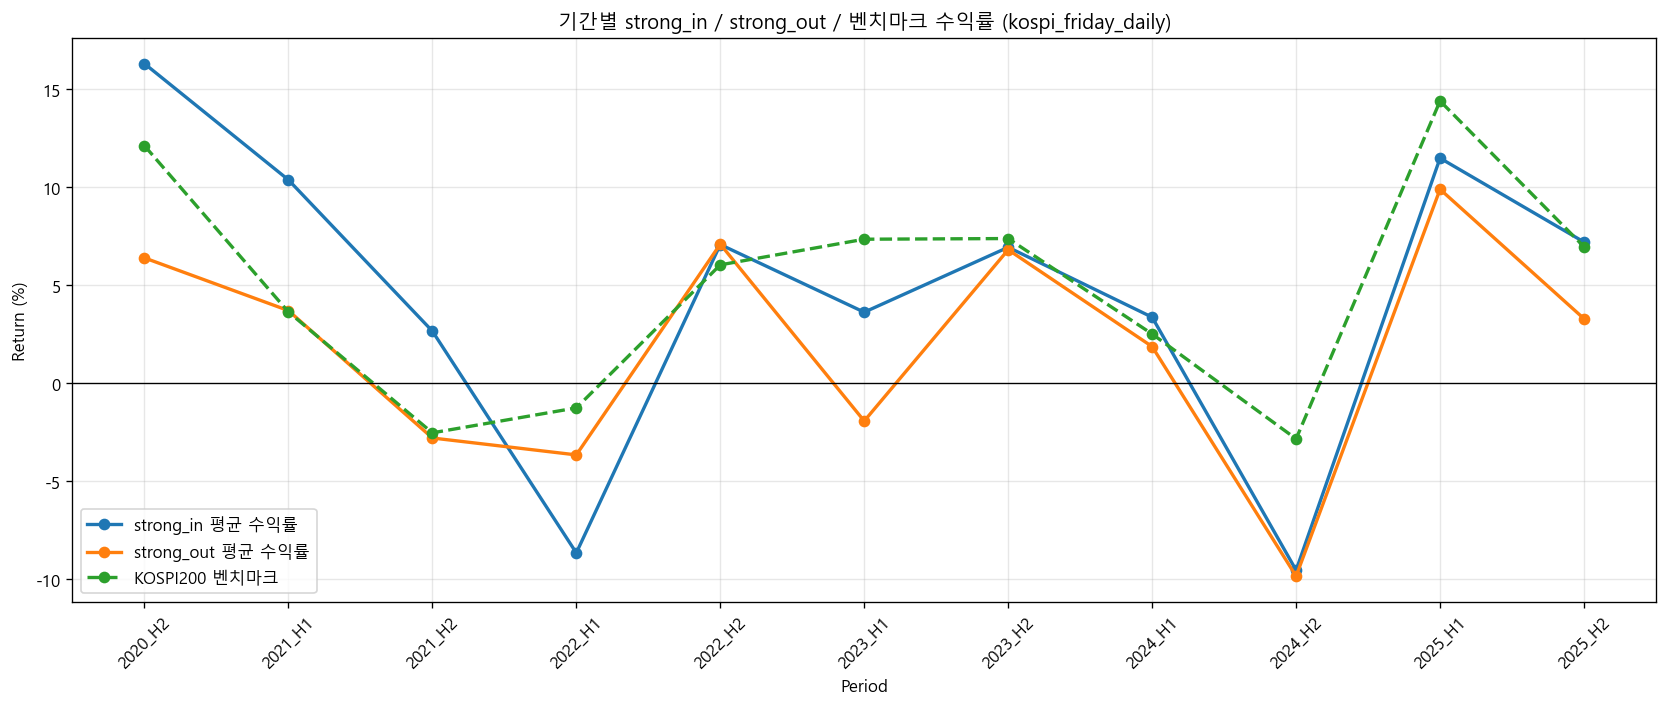

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

plot_df = summary_df.loc[summary_df["status"] == "ok"].copy()
ax.plot(plot_df["period"], plot_df["strong_in_avg_return"], marker="o", linewidth=2, label="strong_in 평균 수익률")
ax.plot(plot_df["period"], plot_df["strong_out_avg_return"], marker="o", linewidth=2, label="strong_out 평균 수익률")
ax.plot(plot_df["period"], plot_df["benchmark_avg_return"], marker="o", linewidth=2, linestyle="--", label="KOSPI200 벤치마크")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"기간별 strong_in / strong_out / 벤치마크 수익률 ({price_source})")
ax.set_xlabel("Period")
ax.set_ylabel("Return (%)")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [26]:
period_to_inspect = "2025_H1"

strong_in_detail = analysis_result[period_to_inspect]["details"]["strong_in"].copy()
strong_in_detail = strong_in_detail[
    ["ticker", "company", "score", "pred_rank", "label_in", "buy_price", "sell_price", "return_pct"]
]
strong_in_detail.rename(columns={"label_in": "actual_in"}, inplace=True)
strong_in_detail


,ticker,company,score,pred_rank,actual_in,buy_price,sell_price,return_pct
0,278470,에이피알,0.996349,115,0.0,76200,131000,71.916010
1,100090,SK오션플랜트,0.828565,179,NaN,14420,20350,41.123440
2,298040,효성중공업,0.999485,84,0.0,507000,680000,34.122288
3,192400,쿠쿠홀딩스,0.169586,200,NaN,24250,30800,27.010309
4,89860,롯데렌탈,0.176369,199,NaN,29450,33600,14.091681
5,6040,동원산업,0.214542,198,1.0,41750,46300,10.898204
6,82740,한화엔진,0.736778,183,NaN,27750,29350,5.765766
7,229640,LS에코에너지,0.790011,180,NaN,32250,34100,5.736434
8,88980,맥쿼리인프라,0.561792,189,NaN,11590,11710,1.035375
9,267270,HD건설기계,0.230633,196,NaN,69100,69300,0.289436


In [27]:
period_to_inspect = "2025_H1"

strong_out_detail = analysis_result[period_to_inspect]["details"]["strong_out"].copy()
strong_out_detail = strong_out_detail[
    ["ticker", "company", "score", "pred_rank", "label_out", "buy_price", "sell_price", "return_pct"]
]
strong_out_detail.rename(columns={"label_out": "actual_out"}, inplace=True)
strong_out_detail


,ticker,company,score,pred_rank,actual_out,buy_price,sell_price,return_pct
0,5420,코스모화학,0.150865,202,0.0,15160,14010,-7.585752
1,241590,화승엔터프라이즈,0.000046,267,NaN,7810,7350,-5.889885
2,105630,한세실업,0.002697,234,1.0,11200,10730,-4.196429
3,6650,대한유화,0.001614,244,0.0,84000,83600,-0.476190
4,361610,SK아이이테크놀로지,0.045405,212,0.0,22700,22800,0.440529
5,9900,명신산업,0.000047,265,NaN,8100,8210,1.358025
6,16380,KG스틸,0.000020,272,NaN,5850,6240,6.666667
7,271940,일진하이솔루스,0.002358,237,1.0,13330,14470,8.552138
8,8730,율촌화학,0.021995,218,0.0,27250,30400,11.559633
9,670,영풍,0.009274,227,0.0,36100,41750,15.650970


## 해석 팁

- `strong_in`은 높을수록 좋고, `strong_in_excess_vs_benchmark`가 `+`일수록 벤치마크 초과 성과입니다.
- `strong_out`은 편출 예상 종목이므로 단순 주가수익률이 낮을수록 신호가 잘 맞았다고 해석할 수 있습니다.
- 현재 가격 소스가 `kospi_friday_daily`라면 매수일이 주간 관측 기준으로 잡히므로, 일별 가격 파일이 생기면 같은 노트북으로 더 정밀하게 재계산할 수 있습니다.


## 11. 핵심 성과 요약

아래 셀은 `Next_v1`의 백테스트 결과를 발표자료나 보고서에 바로 옮길 수 있도록 핵심 수치를 정리합니다.


In [28]:
valid_summary = summary_df.loc[summary_df["status"] == "ok"].copy()
valid_summary = valid_summary.sort_values("period").reset_index(drop=True)

recent_periods = valid_summary.loc[valid_summary["period"].isin(["2025_H1", "2025_H2"])].copy()

performance_kpi_df = pd.DataFrame(
    [
        {"지표": "백테스트 완료 기간 수", "값": int(len(valid_summary)), "설명": "예측 데이터가 존재하는 반기 구간 수"},
        {"지표": "strong_in 벤치마크 초과 기간 수", "값": int((valid_summary["strong_in_excess_vs_benchmark"] > 0).sum()), "설명": "strong_in 평균 수익률이 KOSPI200 BM을 초과한 기간 수"},
        {"지표": "strong_in 플러스 수익 기간 수", "값": int((valid_summary["strong_in_avg_return"] > 0).sum()), "설명": "strong_in 평균 수익률이 0%를 넘은 기간 수"},
        {"지표": "strong_out < 벤치마크 기간 수", "값": int((valid_summary["strong_out_excess_vs_benchmark"] < 0).sum()), "설명": "strong_out 수익률이 벤치마크보다 낮았던 기간 수"},
        {"지표": "전체 기간 strong_in 평균 수익률", "값": valid_summary["strong_in_avg_return"].mean(), "설명": "2020_H2~2025_H2 기준 평균"},
        {"지표": "전체 기간 strong_out 평균 수익률", "값": valid_summary["strong_out_avg_return"].mean(), "설명": "2020_H2~2025_H2 기준 평균"},
        {"지표": "전체 기간 벤치마크 평균 수익률", "값": valid_summary["benchmark_avg_return"].mean(), "설명": "변경 직전 KOSPI200 구성 종목 평균"},
        {"지표": "최근 2개 기간 strong_in 평균 수익률", "값": recent_periods["strong_in_avg_return"].mean(), "설명": "2025_H1, 2025_H2 평균"},
        {"지표": "최근 2개 기간 벤치마크 평균 수익률", "값": recent_periods["benchmark_avg_return"].mean(), "설명": "2025_H1, 2025_H2 평균"},
    ]
)

performance_kpi_view = performance_kpi_df.copy()
performance_kpi_view["값"] = performance_kpi_view.apply(
    lambda row: f'{row["값"]:+.2f}%' if isinstance(row["값"], (float, np.floating)) and "수익률" in row["지표"] else row["값"],
    axis=1,
)
performance_kpi_view


,지표,값,설명
0,백테스트 완료 기간 수,11.0,예측 데이터가 존재하는 반기 구간 수
1,strong_in 벤치마크 초과 기간 수,6.0,strong_in 평균 수익률이 KOSPI200 BM을 초과한 기간 수
2,strong_in 플러스 수익 기간 수,9.0,strong_in 평균 수익률이 0%를 넘은 기간 수
3,strong_out < 벤치마크 기간 수,9.0,strong_out 수익률이 벤치마크보다 낮았던 기간 수
4,전체 기간 strong_in 평균 수익률,+4.62%,2020_H2~2025_H2 기준 평균
5,전체 기간 strong_out 평균 수익률,+1.89%,2020_H2~2025_H2 기준 평균
6,전체 기간 벤치마크 평균 수익률,+4.88%,변경 직전 KOSPI200 구성 종목 평균
7,최근 2개 기간 strong_in 평균 수익률,+9.34%,"2025_H1, 2025_H2 평균"
8,최근 2개 기간 벤치마크 평균 수익률,+10.68%,"2025_H1, 2025_H2 평균"


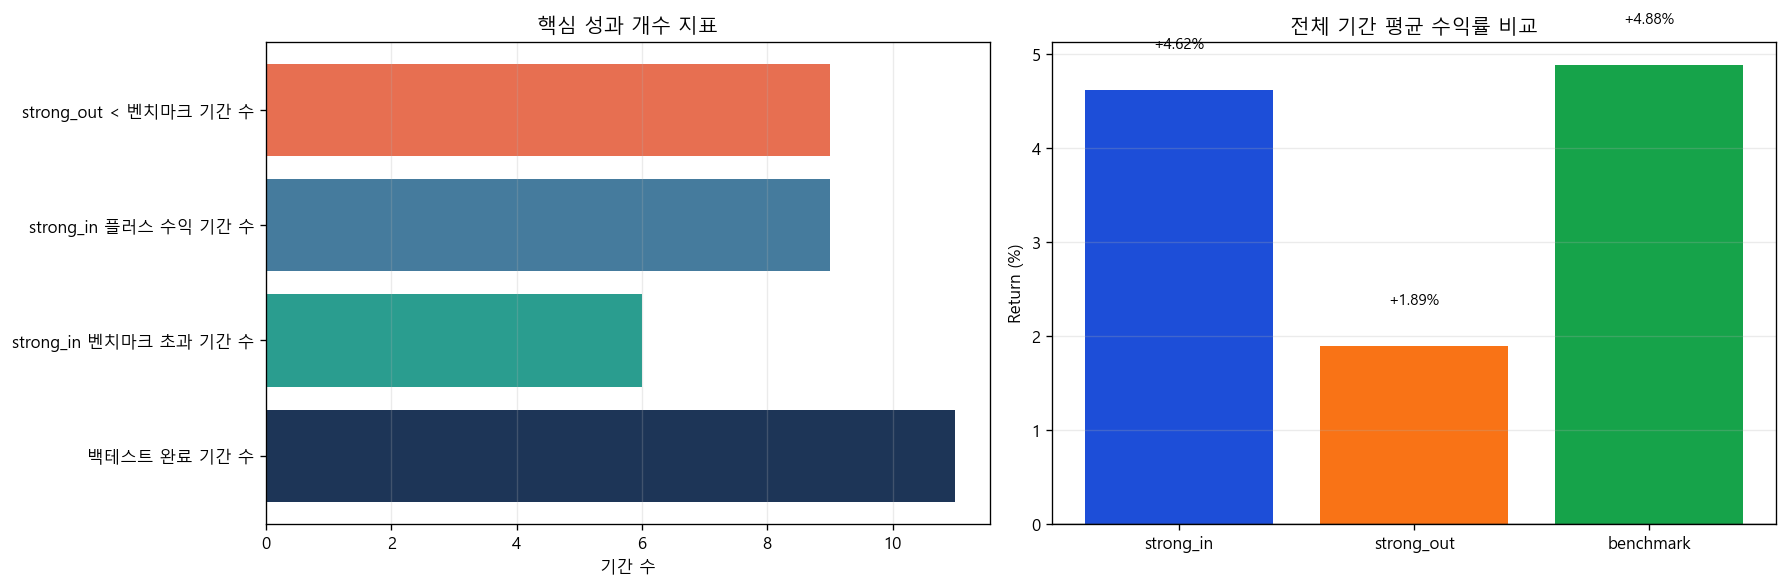

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

count_plot = performance_kpi_df.iloc[:4].copy()
axes[0].barh(count_plot["지표"], count_plot["값"], color=["#1D3557", "#2A9D8F", "#457B9D", "#E76F51"])
axes[0].set_title("핵심 성과 개수 지표")
axes[0].set_xlabel("기간 수")
axes[0].grid(axis="x", alpha=0.25)

return_plot = pd.DataFrame(
    {
        "구분": ["strong_in", "strong_out", "benchmark"],
        "평균수익률": [
            valid_summary["strong_in_avg_return"].mean(),
            valid_summary["strong_out_avg_return"].mean(),
            valid_summary["benchmark_avg_return"].mean(),
        ],
    }
)
bars = axes[1].bar(return_plot["구분"], return_plot["평균수익률"], color=["#1D4ED8", "#F97316", "#16A34A"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("전체 기간 평균 수익률 비교")
axes[1].set_ylabel("Return (%)")
axes[1].grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    y = height + 0.4 if height >= 0 else height - 0.8
    va = "bottom" if height >= 0 else "top"
    axes[1].text(bar.get_x() + bar.get_width() / 2, y, f"{height:+.2f}%", ha="center", va=va, fontsize=9)

plt.tight_layout()
plt.show()


## 12. 기간별 strong_in / strong_out 예측 정확도

여기서는 각 기간별로 아래 3가지를 함께 봅니다.

- `precision`: 예측한 종목 중 실제로 맞은 비율 = `적중 수 / 예측 수`
- `recall`: 실제 종목 중 예측으로 잡아낸 비율 = `적중 수 / 실제 종목 수`
- `F1`: precision과 recall의 균형 지표

시각화는 복잡도를 줄이기 위해 `precision`과 `예측 수 / 실제 수 / 적중 수` 중심으로만 보여주고,
`recall`, `F1`는 표에서 확인하도록 구성합니다.


In [30]:
prediction_eval = predictions.merge(
    labels[["period", "ticker", "label_in", "label_out"]],
    on=["period", "ticker"],
    how="left",
)

prediction_eval["period"] = pd.Categorical(prediction_eval["period"], categories=target_periods, ordered=True)


def calc_signal_metrics(period_df, signal_col, label_col):
    predicted_df = period_df.loc[period_df[signal_col] == 1].copy()
    actual_df = period_df.loc[period_df[label_col].fillna(0) == 1].copy()

    predicted_set = set(predicted_df["ticker"])
    actual_set = set(actual_df["ticker"])
    hit_set = predicted_set & actual_set

    precision = (len(hit_set) / len(predicted_set) * 100) if predicted_set else np.nan
    recall = (len(hit_set) / len(actual_set) * 100) if actual_set else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if pd.notna(precision) and pd.notna(recall) and (precision + recall) > 0
        else np.nan
    )

    return {
        "pred_count": int(len(predicted_set)),
        "actual_count": int(len(actual_set)),
        "hit_count": int(len(hit_set)),
        "precision_pct": precision,
        "recall_pct": recall,
        "f1_pct": f1,
        "predicted_set": predicted_set,
        "actual_set": actual_set,
        "hit_set": hit_set,
    }


prediction_stats_rows = []
prediction_detail_map = {}

for period in target_periods:
    period_df = prediction_eval.loc[prediction_eval["period"] == period].copy()

    if period_df.empty:
        prediction_stats_rows.append(
            {
                "period": period,
                "strong_in_count": np.nan,
                "strong_in_actual_count": np.nan,
                "strong_in_hit": np.nan,
                "strong_in_precision_pct": np.nan,
                "strong_in_recall_pct": np.nan,
                "strong_in_f1_pct": np.nan,
                "strong_out_count": np.nan,
                "strong_out_actual_count": np.nan,
                "strong_out_hit": np.nan,
                "strong_out_precision_pct": np.nan,
                "strong_out_recall_pct": np.nan,
                "strong_out_f1_pct": np.nan,
                "status": "prediction_missing",
            }
        )
        continue

    strong_in_metrics = calc_signal_metrics(period_df, "strong_in", "label_in")
    strong_out_metrics = calc_signal_metrics(period_df, "strong_out", "label_out")

    prediction_stats_rows.append(
        {
            "period": period,
            "strong_in_count": strong_in_metrics["pred_count"],
            "strong_in_actual_count": strong_in_metrics["actual_count"],
            "strong_in_hit": strong_in_metrics["hit_count"],
            "strong_in_precision_pct": strong_in_metrics["precision_pct"],
            "strong_in_recall_pct": strong_in_metrics["recall_pct"],
            "strong_in_f1_pct": strong_in_metrics["f1_pct"],
            "strong_out_count": strong_out_metrics["pred_count"],
            "strong_out_actual_count": strong_out_metrics["actual_count"],
            "strong_out_hit": strong_out_metrics["hit_count"],
            "strong_out_precision_pct": strong_out_metrics["precision_pct"],
            "strong_out_recall_pct": strong_out_metrics["recall_pct"],
            "strong_out_f1_pct": strong_out_metrics["f1_pct"],
            "status": "ok",
        }
    )

    prediction_detail_map[period] = {
        "strong_in": strong_in_metrics,
        "strong_out": strong_out_metrics,
    }

prediction_stats_df = pd.DataFrame(prediction_stats_rows).sort_values("period").reset_index(drop=True)

prediction_stats_view = prediction_stats_df.copy()
for col in [
    "strong_in_precision_pct",
    "strong_in_recall_pct",
    "strong_in_f1_pct",
    "strong_out_precision_pct",
    "strong_out_recall_pct",
    "strong_out_f1_pct",
]:
    prediction_stats_view[col] = prediction_stats_view[col].map(lambda x: f"{x:.1f}%" if pd.notna(x) else "N/A")

prediction_stats_view


,period,strong_in_count,strong_in_actual_count,strong_in_hit,strong_in_precision_pct,strong_in_recall_pct,strong_in_f1_pct,strong_out_count,strong_out_actual_count,strong_out_hit,strong_out_precision_pct,strong_out_recall_pct,strong_out_f1_pct,status
0,2020_H1,NaN,NaN,NaN,N/A,N/A,N/A,NaN,NaN,NaN,N/A,N/A,N/A,prediction_missing
1,2020_H2,23.0,8.0,8.0,34.8%,100.0%,51.6%,10.0,6.0,6.0,60.0%,100.0%,75.0%,ok
2,2021_H1,17.0,4.0,4.0,23.5%,100.0%,38.1%,10.0,6.0,5.0,50.0%,83.3%,62.5%,ok
3,2021_H2,15.0,2.0,2.0,13.3%,100.0%,23.5%,11.0,6.0,5.0,45.5%,83.3%,58.8%,ok
4,2022_H1,15.0,3.0,3.0,20.0%,100.0%,33.3%,8.0,8.0,5.0,62.5%,62.5%,62.5%,ok
5,2022_H2,11.0,1.0,1.0,9.1%,100.0%,16.7%,10.0,1.0,1.0,10.0%,100.0%,18.2%,ok
6,2023_H1,6.0,5.0,5.0,83.3%,100.0%,90.9%,5.0,4.0,4.0,80.0%,100.0%,88.9%,ok
7,2023_H2,14.0,7.0,7.0,50.0%,100.0%,66.7%,8.0,8.0,8.0,100.0%,100.0%,100.0%,ok
8,2024_H1,15.0,3.0,3.0,20.0%,100.0%,33.3%,13.0,7.0,6.0,46.2%,85.7%,60.0%,ok
9,2024_H2,12.0,3.0,3.0,25.0%,100.0%,40.0%,12.0,5.0,5.0,41.7%,100.0%,58.8%,ok


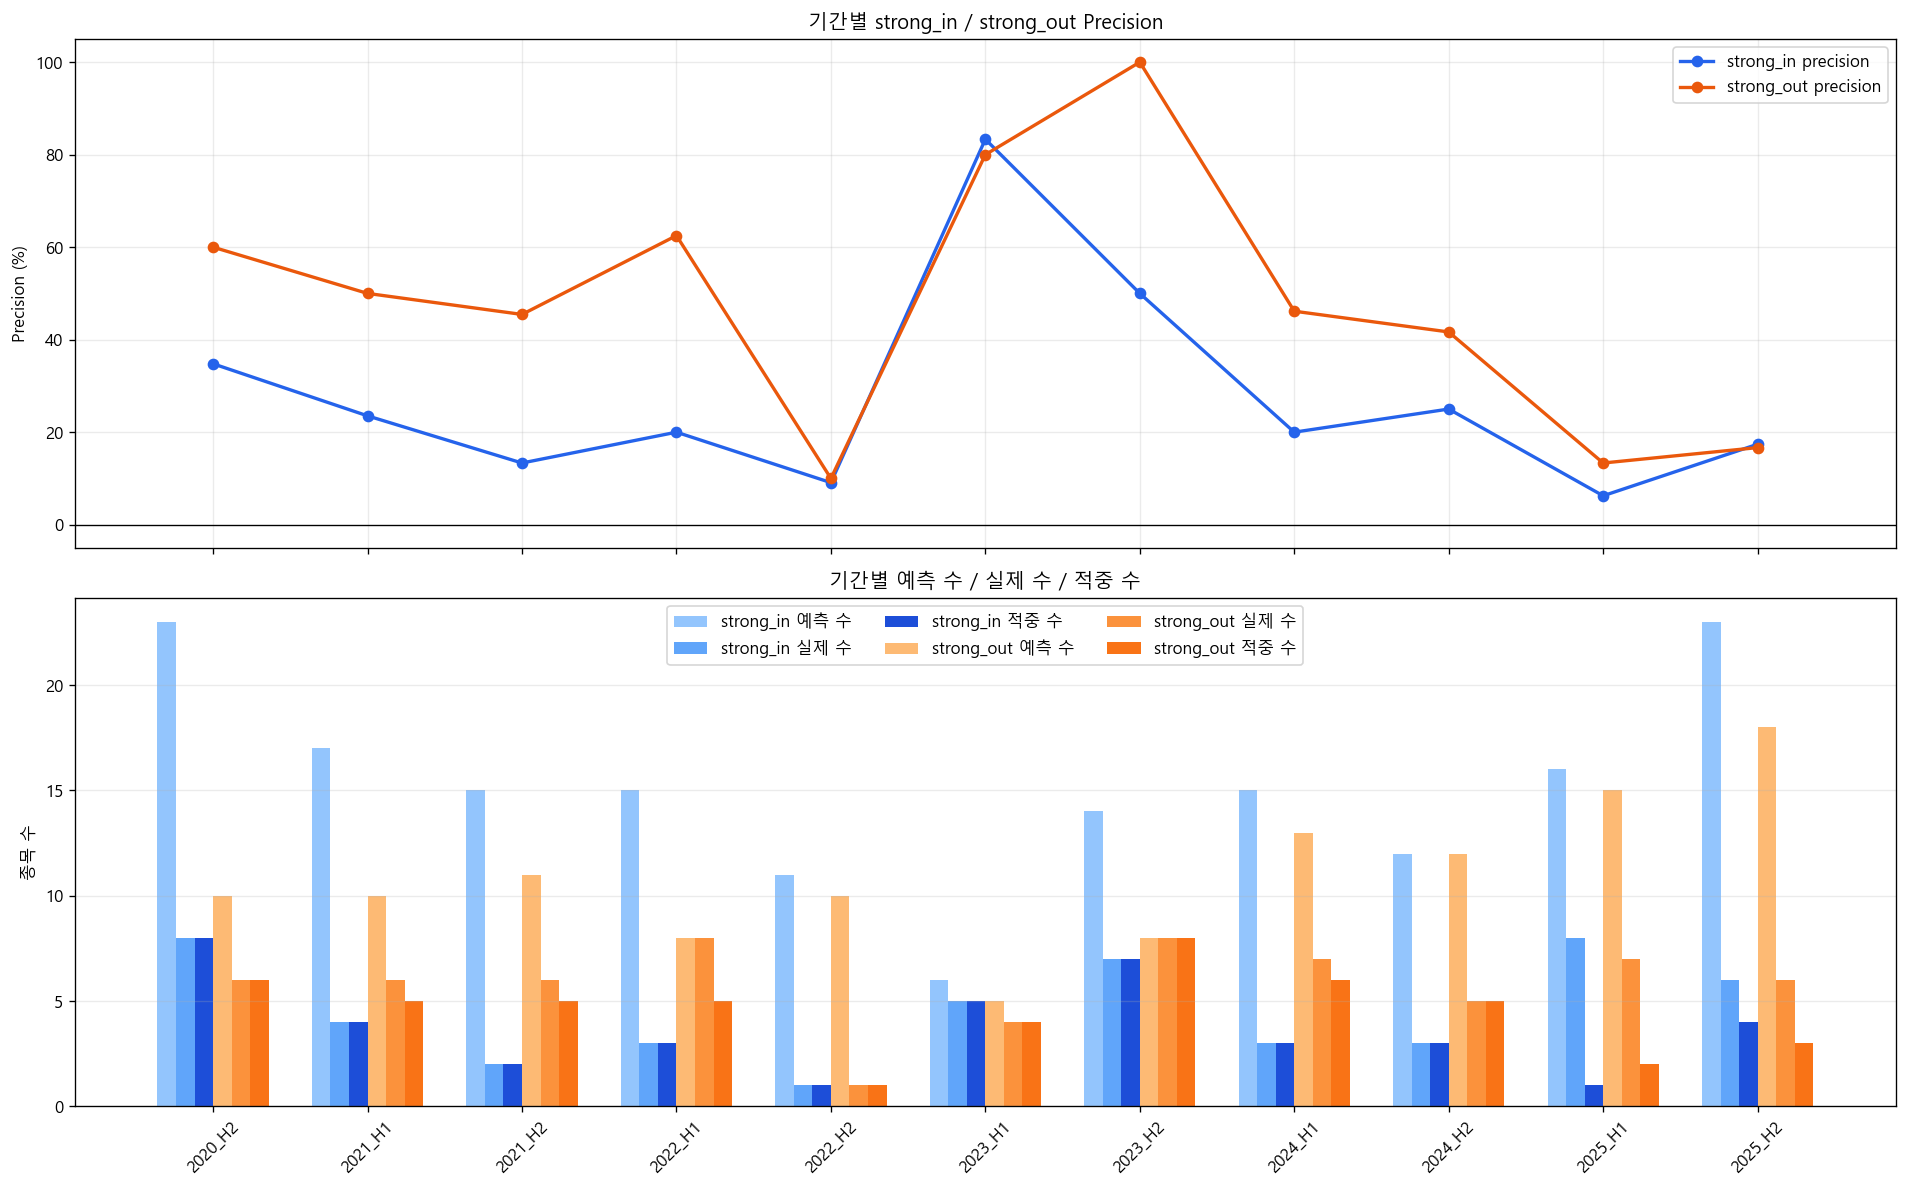

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

plot_stats = prediction_stats_df.loc[prediction_stats_df["status"] == "ok"].copy()
x = np.arange(len(plot_stats))

axes[0].plot(plot_stats["period"].astype(str), plot_stats["strong_in_precision_pct"], marker="o", linewidth=2, color="#2563EB", label="strong_in precision")
axes[0].plot(plot_stats["period"].astype(str), plot_stats["strong_out_precision_pct"], marker="o", linewidth=2, color="#EA580C", label="strong_out precision")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Precision (%)")
axes[0].set_title("기간별 strong_in / strong_out Precision")
axes[0].grid(alpha=0.25)
axes[0].legend()

width = 0.12
axes[1].bar(x - width * 2.5, plot_stats["strong_in_count"], width=width, color="#93C5FD", label="strong_in 예측 수")
axes[1].bar(x - width * 1.5, plot_stats["strong_in_actual_count"], width=width, color="#60A5FA", label="strong_in 실제 수")
axes[1].bar(x - width * 0.5, plot_stats["strong_in_hit"], width=width, color="#1D4ED8", label="strong_in 적중 수")
axes[1].bar(x + width * 0.5, plot_stats["strong_out_count"], width=width, color="#FDBA74", label="strong_out 예측 수")
axes[1].bar(x + width * 1.5, plot_stats["strong_out_actual_count"], width=width, color="#FB923C", label="strong_out 실제 수")
axes[1].bar(x + width * 2.5, plot_stats["strong_out_hit"], width=width, color="#F97316", label="strong_out 적중 수")
axes[1].set_ylabel("종목 수")
axes[1].set_title("기간별 예측 수 / 실제 수 / 적중 수")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_stats["period"].astype(str), rotation=45)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(ncol=3)

plt.tight_layout()
plt.show()


In [32]:
prediction_summary_kpi = pd.DataFrame(
    [
        {
            "지표": "strong_in 전체 평균 precision",
            "값": prediction_stats_df.loc[prediction_stats_df["status"] == "ok", "strong_in_precision_pct"].mean(),
        },
        {
            "지표": "strong_out 전체 평균 precision",
            "값": prediction_stats_df.loc[prediction_stats_df["status"] == "ok", "strong_out_precision_pct"].mean(),
        },
        {
            "지표": "strong_in 전체 평균 recall",
            "값": prediction_stats_df.loc[prediction_stats_df["status"] == "ok", "strong_in_recall_pct"].mean(),
        },
        {
            "지표": "strong_out 전체 평균 recall",
            "값": prediction_stats_df.loc[prediction_stats_df["status"] == "ok", "strong_out_recall_pct"].mean(),
        },
        {
            "지표": "strong_in 최고 precision",
            "값": prediction_stats_df.loc[prediction_stats_df["status"] == "ok", "strong_in_precision_pct"].max(),
        },
        {
            "지표": "strong_out 최고 precision",
            "값": prediction_stats_df.loc[prediction_stats_df["status"] == "ok", "strong_out_precision_pct"].max(),
        },
        {
            "지표": "strong_in 총 예측 수",
            "값": int(prediction_stats_df["strong_in_count"].fillna(0).sum()),
        },
        {
            "지표": "strong_in 총 적중 수",
            "값": int(prediction_stats_df["strong_in_hit"].fillna(0).sum()),
        },
        {
            "지표": "strong_out 총 예측 수",
            "값": int(prediction_stats_df["strong_out_count"].fillna(0).sum()),
        },
        {
            "지표": "strong_out 총 적중 수",
            "값": int(prediction_stats_df["strong_out_hit"].fillna(0).sum()),
        },
    ]
)

prediction_summary_view = prediction_summary_kpi.copy()
prediction_summary_view["값"] = prediction_summary_view.apply(
    lambda row: f'{row["값"]:.1f}%' if isinstance(row["값"], (float, np.floating)) and any(key in row["지표"] for key in ["precision", "recall"]) else row["값"],
    axis=1,
)
prediction_summary_view


,지표,값
0,strong_in 전체 평균 precision,27.5%
1,strong_out 전체 평균 precision,47.8%
2,strong_in 전체 평균 recall,89.0%
3,strong_out 전체 평균 recall,81.2%
4,strong_in 최고 precision,83.3%
5,strong_out 최고 precision,100.0%
6,strong_in 총 예측 수,167.0
7,strong_in 총 적중 수,41.0
8,strong_out 총 예측 수,120.0
9,strong_out 총 적중 수,50.0


## 13. 기간별 예측 종목명과 실제 종목명 비교

각 기간별로 `strong_in`, `strong_out`에 대해 아래를 확인할 수 있게 만든 섹션입니다.

- 예측 종목 목록
- 실제 편입/편출 종목 목록
- 적중 여부 체크
- 예측만 됨 / 실제만 존재 / 적중 예측 구분


In [33]:
period_to_check = "2025_H1"
signal_to_check = "strong_out"  # "strong_in" 또는 "strong_out"

label_col = "label_in" if signal_to_check == "strong_in" else "label_out"
period_df = prediction_eval.loc[prediction_eval["period"] == period_to_check].copy()

predicted_rows = period_df.loc[period_df[signal_to_check] == 1, ["ticker", "company", "score", "pred_rank"]].copy()
actual_rows = period_df.loc[period_df[label_col].fillna(0) == 1, ["ticker", "company"]].copy()

predicted_set = set(predicted_rows["ticker"])
actual_set = set(actual_rows["ticker"])
hit_set = predicted_set & actual_set

predicted_compare = predicted_rows.copy()
predicted_compare["결과"] = predicted_compare["ticker"].map(lambda x: "적중 예측" if x in hit_set else "예측만 됨")
predicted_compare["실제해당여부"] = predicted_compare["ticker"].map(lambda x: "Y" if x in actual_set else "N")
predicted_compare = predicted_compare.sort_values(["결과", "pred_rank", "ticker"]).reset_index(drop=True)

actual_compare = actual_rows.copy()
actual_compare["결과"] = actual_compare["ticker"].map(lambda x: "적중 예측" if x in hit_set else "실제만 존재")
actual_compare["예측여부"] = actual_compare["ticker"].map(lambda x: "Y" if x in predicted_set else "N")
actual_compare = actual_compare.sort_values(["결과", "ticker"]).reset_index(drop=True)

summary_compare = pd.DataFrame(
    {
        "구분": ["예측 종목 수", "실제 종목 수", "적중 수", "precision", "recall"],
        "값": [
            len(predicted_set),
            len(actual_set),
            len(hit_set),
            f'{(len(hit_set) / len(predicted_set) * 100):.1f}%' if predicted_set else "N/A",
            f'{(len(hit_set) / len(actual_set) * 100):.1f}%' if actual_set else "N/A",
        ],
    }
)

display(summary_compare)
display(predicted_compare)
display(actual_compare)


,구분,값
0,예측 종목 수,15
1,실제 종목 수,7
2,적중 수,2
3,precision,13.3%
4,recall,28.6%


,ticker,company,score,pred_rank,결과,실제해당여부
0,5420,코스모화학,0.150865,202,예측만 됨,N
1,210,DL,0.145353,204,예측만 됨,N
2,5250,녹십자홀딩스,0.047623,211,예측만 됨,N
3,361610,SK아이이테크놀로지,0.045405,212,예측만 됨,N
4,8730,율촌화학,0.021995,218,예측만 됨,N
5,4800,효성,0.020732,219,예측만 됨,N
6,670,영풍,0.009274,227,예측만 됨,N
7,32350,롯데관광개발,0.001934,241,예측만 됨,N
8,6650,대한유화,0.001614,244,예측만 됨,N
9,93370,후성,0.000440,251,예측만 됨,N


,ticker,company,결과,예측여부
0,1120,LX인터내셔널,실제만 존재,N
1,1570,금양,실제만 존재,N
2,1740,SK네트웍스,실제만 존재,N
3,336260,두산퓨얼셀,실제만 존재,N
4,5070,코스모신소재,실제만 존재,N
5,105630,한세실업,적중 예측,Y
6,271940,일진하이솔루스,적중 예측,Y


In [34]:
comparison_rows = []

for period in [p for p in target_periods if p in prediction_eval["period"].astype(str).tolist()]:
    period_df = prediction_eval.loc[prediction_eval["period"].astype(str) == period].copy()
    for signal_col, label_col in [("strong_in", "label_in"), ("strong_out", "label_out")]:
        predicted = period_df.loc[period_df[signal_col] == 1, ["ticker", "company", "score", "pred_rank"]].copy()
        actual = period_df.loc[period_df[label_col].fillna(0) == 1, ["ticker", "company"]].copy()

        predicted_set = set(predicted["ticker"])
        actual_set = set(actual["ticker"])
        hit_set = predicted_set & actual_set

        comparison_rows.append(
            {
                "period": period,
                "signal": signal_col,
                "predicted_names": ", ".join(predicted.sort_values("pred_rank")["company"].fillna(predicted["ticker"]).astype(str).tolist()),
                "actual_names": ", ".join(actual.sort_values("ticker")["company"].fillna(actual["ticker"]).astype(str).tolist()),
                "hit_names": ", ".join(
                    predicted.loc[predicted["ticker"].isin(hit_set)].sort_values("pred_rank")["company"].fillna(predicted["ticker"]).astype(str).tolist()
                ),
                "pred_only_names": ", ".join(
                    predicted.loc[~predicted["ticker"].isin(hit_set)].sort_values("pred_rank")["company"].fillna(predicted["ticker"]).astype(str).tolist()
                ),
                "actual_only_names": ", ".join(
                    actual.loc[~actual["ticker"].isin(hit_set)].sort_values("ticker")["company"].fillna(actual["ticker"]).astype(str).tolist()
                ),
            }
        )

comparison_name_df = pd.DataFrame(comparison_rows)
comparison_name_df


,period,signal,predicted_names,actual_names,hit_names,pred_only_names,actual_only_names
0,2020_H2,strong_in,"한진칼, 포스코퓨처엠, KG스틸, 두산퓨얼셀, 신풍제약, 삼양식품, F&F홀딩스, ...","씨에스윈드, 지누스, 신풍제약, 대웅, 삼양식품, 두산퓨얼셀, 키움증권, 남선알미늄","두산퓨얼셀, 신풍제약, 삼양식품, 대웅, 키움증권, 지누스, 남선알미늄, 씨에스윈드","한진칼, 포스코퓨처엠, KG스틸, F&F홀딩스, 롯데관광개발, 태영건설, HMM, ...",
1,2020_H2,strong_out,"에스엘, 동아에스티, DB하이텍, 동아쏘시오홀딩스, LF, KG모빌리티, BGF, ...","유니드, 동아에스티, 남해화학, BGF, 동아쏘시오홀딩스, LF","동아에스티, 동아쏘시오홀딩스, LF, BGF, 유니드, 남해화학","에스엘, DB하이텍, KG모빌리티, 한국단자",
2,2021_H1,strong_in,"두산퓨얼셀, 신풍제약, 대웅, 키움증권, 삼양식품, 효성티앤씨, HS효성첨단소재, ...","대한전선, 효성티앤씨, HS효성첨단소재, 동원산업","효성티앤씨, HS효성첨단소재, 동원산업, 대한전선","두산퓨얼셀, 신풍제약, 대웅, 키움증권, 삼양식품, 지누스, 씨에스윈드, 맥쿼리인프...",
3,2021_H1,strong_out,"동아에스티, 애경산업, 동아쏘시오홀딩스, SPC삼립, 빙그레, 삼양사, 세아베스틸지...","HDC, 삼양사, 애경산업, 빙그레, SPC삼립,","애경산업, SPC삼립, 빙그레, 삼양사,","동아에스티, 동아쏘시오홀딩스, 세아베스틸지주, BGF, 유니드",HDC
4,2021_H2,strong_in,"효성티앤씨, HS효성첨단소재, 대한전선, 메리츠금융지주, 동원산업, 에스엘, 맥쿼리...","메리츠금융지주, 에스엘","메리츠금융지주, 에스엘","효성티앤씨, HS효성첨단소재, 대한전선, 동원산업, 맥쿼리인프라, , NHN, 효성...",
5,2021_H2,strong_out,"롯데하이마트, LX하우시스, 삼양식품, HDC, 일양약품, , 고려제강, SPC삼립...","LX하우시스, , 이노션, 삼양식품, 롯데하이마트, 일양약품","롯데하이마트, LX하우시스, 삼양식품, 일양약품,","HDC, 고려제강, SPC삼립, , 애경산업, 삼양사",이노션
6,2022_H1,strong_in,"명신산업, 메리츠금융지주, 에스엘, 하나투어, , 한일시멘트, 맥쿼리인프라, KCC...","한일시멘트, 하나투어,","하나투어, , 한일시멘트","명신산업, 메리츠금융지주, 에스엘, 맥쿼리인프라, KCC글라스, 더존비즈온, 한화투...",
7,2022_H1,strong_out,"이노션, 부광약품, , SNT모티브, 넥센타이어, 쿠쿠홀딩스, 롯데하이마트, 삼양식품","쿠쿠홀딩스, 넥센타이어, 부광약품, 영진약품, , SK디스커버리, SNT모티브, C...","부광약품, , SNT모티브, 넥센타이어, 쿠쿠홀딩스","이노션, 롯데하이마트, 삼양식품","영진약품, SK디스커버리, CJ CGV"
8,2022_H2,strong_in,"F&F, 케이카, 에스디바이오센서, 일진하이솔루스, 한일시멘트, 롯데웰푸드, , 하...",롯데웰푸드,롯데웰푸드,"F&F, 케이카, 에스디바이오센서, 일진하이솔루스, 한일시멘트, , 하나투어, 맥쿼...",
9,2022_H2,strong_out,"SK디스커버리, SNT모티브, 영진약품, 넥센타이어, 삼양홀딩스, JW중외제약, ,...",삼양홀딩스,삼양홀딩스,"SK디스커버리, SNT모티브, 영진약품, 넥센타이어, JW중외제약, , 부광약품, ...",
